In [17]:
import numpy as np
import matplotlib.pyplot as plt

## Model

Reactions:
1) prey birth         : $X \rightarrow 2X$
2) predation          : $X + Y \rightarrow 2Y$
3) predator death     : $Y \rightarrow ∅$


In [ ]:

def propensity(x, params):
    """
    Compute reaction propensities for Lotka-Volterra.

    x: state vector [Prey, Predator]
    params: dict with parameters
    """
    alpha = params["alpha"]   # prey growth
    beta  = params["beta"]    # predation
    gamma = params["gamma"]   # predator death

    prey = x[0]
    pred = x[1]

    # reactions:
    # 1) prey birth         : X -> 2X
    # 2) predation          : X + Y -> 2Y
    # 3) predator death     : Y -> ∅
    a1 = alpha * prey
    a2 = beta * prey * pred
    a3 = gamma * pred

    return np.array([a1, a2, a3])


def stoichiometry():
    """
    Stoichiometry matrix:
    rows = species [prey, predator]
    columns = reactions
    """
    return np.array([
        [1,  -1,  0],   # prey change
        [0,   1, -1]    # predator change
    ])



## SSA

In [52]:
# ----------------------------
# Gillespie SSA
# ----------------------------

def gillespie(x0, params, t_max, plot_on=False):
    S = stoichiometry()

    t = 0.0
    x = x0.copy()

    T = [t]
    X = [x.copy()]

    while t < t_max:
        a = propensity(x, params)
        a0 = np.sum(a)

        if a0 <= 0:
            break

        # time to next reaction
        r1 = np.random.rand()
        tau = -np.log(r1) / a0
        t += tau

        # choose reaction
        r2 = np.random.rand()
        cumulative = np.cumsum(a) / a0
        j = np.searchsorted(cumulative, r2)

        # update state
        x = x + S[:, j]

        # avoid negative populations
        x = np.maximum(x, 0)

        # store
        T.append(t)
        X.append(x.copy())

    T,X = np.array(T), np.array(X)

    if plot_on:

        # ----------------------------
        # Plot results
        # ----------------------------

        plt.figure(figsize=(8, 4))
        plt.step(T, X[:, 0], where="post", label="Prey")
        plt.step(T, X[:, 1], where="post", label="Predator")
        plt.xlabel("Time")
        plt.ylabel("Population")
        plt.title("Stochastic Lotka-Volterra (SSA)")
        plt.legend()
        plt.grid()
        plt.show()

    return T,X


## Parameters and tests

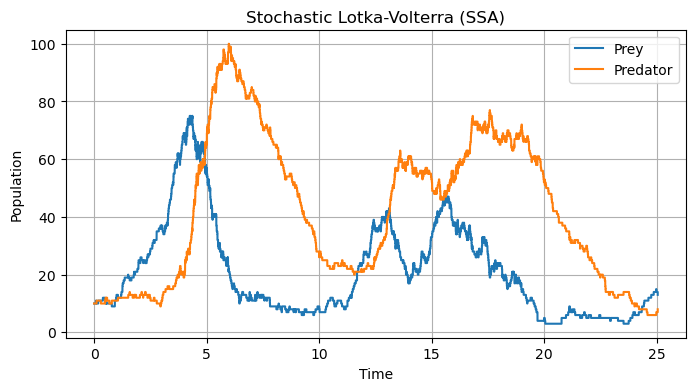

In [90]:
t_end = 25

params = {
    "alpha": 1,   # prey growth rate
    "beta": 0.02,   # predation rate
    "gamma": 0.5    # predator death rate
}

x0 = np.array([10, 10])   # [prey, predator]

T, X = gillespie(x0, params, t_end, plot_on=True) # run SSA

## Multiple runs

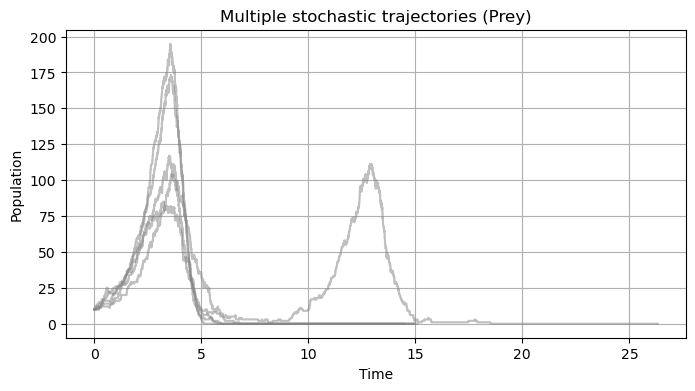

In [58]:

plt.figure(figsize=(8, 4))

for i in range(5):
    T, X = gillespie(x0, params, t_end, plot_on=False)
    plt.step(T, X[:, 0], where="post", alpha=0.5, color="grey")

plt.title("Multiple stochastic trajectories (Prey)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.grid()
plt.show()
